# About Dataset
Bank marketing campaigns dataset analysis # Opening a Term Deposit
It is a dataset that describing Portugal bank marketing campaigns results.
Conducted campaigns were based mostly on direct phone calls, offering bank client to place a term deposit.
If after all marking afforts client had agreed to place deposit - target variable marked 'yes', otherwise 'no'

Sourse of the data
https://archive.ics.uci.edu/ml/datasets/bank+marketing

Citation Request:

This dataset is public available for research. The details are described in S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014

Title: Bank Marketing (with social/economic context)

Sources
Created by: Sérgio Moro (ISCTE-IUL), Paulo Cortez (Univ. Minho) and Paulo Rita (ISCTE-IUL) @ 2014

Past Usage:

The full dataset (bank-additional-full.csv) was described and analyzed in:

S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems (2014), doi:10.1016/j.dss.2014.03.001.

Relevant Information:

This dataset is based on "Bank Marketing" UCI dataset (please check the description at: http://archive.ics.uci.edu/ml/datasets/Bank+Marketing).
The data is enriched by the addition of five new social and economic features/attributes (national wide indicators from a ~10M population country), published by the Banco de Portugal and publicly available at: https://www.bportugal.pt/estatisticasweb.
This dataset is almost identical to the one used in [Moro et al., 2014] (it does not include all attributes due to privacy concerns).
Using the rminer package and R tool (http://cran.r-project.org/web/packages/rminer/), we found that the addition of the five new social and economic attributes (made available here) lead to substantial improvement in the prediction of a success, even when the duration of the call is not included. Note: the file can be read in R using: d=read.table("bank-additional-full.csv",header=TRUE,sep=";")

The binary classification goal is to predict if the client will subscribe a bank term deposit (variable y).

Number of Instances: 41188 for bank-additional-full.csv

Number of Attributes: 20 + output attribute.

Attribute information:

For more information, read [Moro et al., 2014].

Input variables:

bank client data:
*1 - age (numeric)

*2 - job : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")

*3 - marital : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)

*4 - education (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")

5 - default: has credit in default? (categorical: "no","yes","unknown") # 신용공여한도 유무 # 컬럼명 변경

6 - housing: has housing loan? (categorical: "no","yes","unknown")

7 - loan: has personal loan? (categorical: "no","yes","unknown")

related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: "cellular","telephone")
*9 - month: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec") # 월별로 가입유무 상이 가능성 있음. 

*10 - day_of_week: last contact day of the week (categorical: "mon","tue","wed","thu","fri") # 요일별로 가입유무 상이 가능성 있음.

*11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. 

-> 가입유무에 절대적인 영향을 미치는 피처로서 챗봇과의 대화량이 많을 수록 가입가능성 높아질 것으로 추측되며, 데이터 분석시는 제외.

other attributes:
*12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact) -> 접촉횟수

*13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted) -> 마지막 접촉 후 경과시간

*14 - previous: number of contacts performed before this campaign and for this client (numeric) # 본 캠페인 이전 접촉횟수

1515 - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success") # 예전 마케팅 성공이력

social and economic context attributes
*16 - emp.var.rate: employment variation rate - quarterly indicator (numeric) # 분기별 고용률

*17 - cons.price.idx: consumer price index - monthly indicator (numeric) # 월별 소비자 물가지수

*18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric) # 월별 소비자심리지수

*19 - euribor3m: euribor 3 month rate - daily indicator (numeric) # 일별 유럽은행간 금리

20 - nr.employed: number of employees - quarterly indicator (numeric) # 고용인원수

Output variable (desired target):

21 - y - has the client subscribed a term deposit? (binary: "yes","no")

Missing Attribute Values: There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.

View less
Usability
10.00

License
CC BY-NC-SA 4.0

Expected update frequency
Never

Tags
Business
Exploratory Data Analysis


In [1]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# 실제 결측값 자료는 unknown으로 표기됨. # 결측치 있어도 분석이 가능한 XGBoost 활용
unknown_counts = (df == 'unknown').sum()
print(unknown_counts)

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [4]:
# 컬럼명 변경. 신용공여유무를 확인하는 컬럼명을 보다 쉽게 변경
df = df.rename(columns={'default': 'credit'})

In [5]:
# duration 컬럼 삭제
# 가입유무에 절대적인 영향을 미치는 피처로서 챗봇과의 대화량이 많을 수록 가입가능성 높아질 것으로 추측되며, 데이터 분석시는 제외.
df.drop(columns=['duration'], inplace=True)

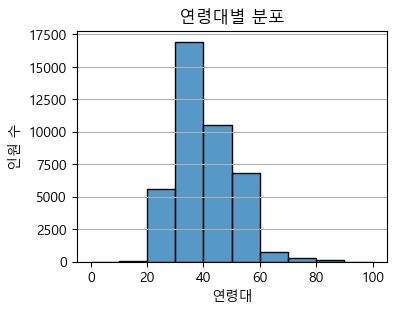

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')  # Windows
plt.figure(figsize=(4, 3))
sns.histplot(df['age'], bins=range(0, 101, 10), kde=False)
plt.title("연령대별 분포")
plt.xlabel("연령대")
plt.ylabel("인원 수")
plt.grid(axis='y')
plt.show()

In [7]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [9]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [10]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

In [11]:
df['credit'].unique()

array(['no', 'unknown', 'yes'], dtype=object)

In [12]:
df['housing'].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [13]:
df['loan'].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [14]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [15]:
# 타겟값 포함한 모드 yes와 no를 수치형 자료로 변환
df = df.replace({'yes': 1, 'no': 0})

C:\Users\User\AppData\Local\Temp\ipykernel_17644\1757520416.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0})


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   credit          41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [17]:
pd.crosstab(df['job'], df['y'], normalize='index') # 은퇴층과 학생층의 성공률이 높음. 

y,0,1
job,,
admin.,0.870274,0.129726
blue-collar,0.931057,0.068943
entrepreneur,0.914835,0.085165
housemaid,0.900000,0.100000
management,0.887825,0.112175
retired,0.747674,0.252326
self-employed,0.895144,0.104856
services,0.918619,0.081381
student,0.685714,0.314286


In [19]:
df.groupby('marital')['y'].mean() # 유의미한 결과 없음. 

marital
divorced    0.103209
married     0.101573
single      0.140041
unknown     0.150000
Name: y, dtype: float64

In [20]:
pd.crosstab(df['education'], df['y'], normalize='index') 
# 전반적으로 학력이 낮을 수록 가입이 높다는 추정은 가능하나 변별력있는 자료 아님.
# 상대적으로 문맹률이 낮고, 기초학력이 높은 우리나라에 적용하기 어려운 데이터로 판단됨. 

y,0,1
education,,
basic.4y,0.897510,0.102490
basic.6y,0.917976,0.082024
basic.9y,0.921754,0.078246
high.school,0.891645,0.108355
illiterate,0.777778,0.222222
professional.course,0.886515,0.113485
university.degree,0.862755,0.137245
unknown,0.854997,0.145003


In [22]:
df = df.drop(columns=['marital', 'education'])
df.columns

Index(['age', 'job', 'credit', 'housing', 'loan', 'contact', 'month',
       'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y'],
      dtype='object')

In [23]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [24]:
unknown_counts = (df == 'unknown').sum()
print(unknown_counts)

age                  0
job                330
credit            8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [28]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [32]:
# 매핑
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# 적용
df['month'] = df['month'].map(month_map)

In [29]:
df['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [33]:
# 요일 매핑
day_map = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5
}

# 매핑 적용
df['day_of_week'] = df['day_of_week'].map(day_map)

In [30]:
df['contact'].unique()

array(['telephone', 'cellular'], dtype=object)

In [34]:
df = df.drop(columns=['contact'])

In [31]:
df['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [35]:
poutcome_map = {
    'failure': 0,
    'nonexistent': 0.5,
    'success': 1,
}

# 매핑 적용
df['poutcome'] = df['poutcome'].map(poutcome_map)

In [37]:
# 실질적인 결측치인 "unknown" 값을 결측치로 변경
df = df.replace("unknown", np.nan)

C:\Users\User\AppData\Local\Temp\ipykernel_17644\642105928.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("unknown", np.nan)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   credit          32591 non-null  float64
 3   housing         40198 non-null  float64
 4   loan            40198 non-null  float64
 5   month           41188 non-null  int64  
 6   day_of_week     41188 non-null  int64  
 7   campaign        41188 non-null  int64  
 8   pdays           41188 non-null  int64  
 9   previous        41188 non-null  int64  
 10  poutcome        41188 non-null  float64
 11  emp.var.rate    41188 non-null  float64
 12  cons.price.idx  41188 non-null  float64
 13  cons.conf.idx   41188 non-null  float64
 14  euribor3m       41188 non-null  float64
 15  nr.employed     41188 non-null  float64
 16  y               41188 non-null  int64  
dtypes: float64(9), int64(7), object

In [39]:
# 범주형 데이터 보간 전략
# 다른 범주형 데이터 포함하여 임시 수치 인코딩
# 수치형으로 변경후 KNNImputer로 보간

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

# 1. 범주형 컬럼과 수치형 컬럼 구분
categorical_cols = ['credit', 'housing', 'loan', 'poutcome']
numerical_cols = ['age', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# 2. 복사본 생성
df_encoded = df.copy()

# 3. 결측치 처리 전, OrdinalEncoder로 범주형 인코딩 (job 제외)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[categorical_cols] = encoder.fit_transform(df_encoded[categorical_cols])

# 4. job 컬럼 임시 인코딩 (결측 포함 허용)
job_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded['job_encoded'] = job_encoder.fit_transform(df[['job']])

# 5. KNNImputer 적용을 위한 전체 컬럼 구성
all_input_cols = numerical_cols + categorical_cols + ['job_encoded']
imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(df_encoded[all_input_cols])

# 6. job 인코딩 값 복원
job_imputed_numeric = np.round(imputed[:, -1]).astype(int)
job_labels = job_encoder.categories_[0].tolist()

# 7. 안전하게 범주형으로 역변환 (범위 초과 시 'unknown')
df['job_imputed'] = [job_labels[i] if 0 <= i < len(job_labels) else 'unknown' for i in job_imputed_numeric]

# 8. 결과 확인
print(df[['job', 'job_imputed']].head(10))


           job  job_imputed
0    housemaid    housemaid
1     services     services
2     services     services
3       admin.       admin.
4     services     services
5     services     services
6       admin.       admin.
7  blue-collar  blue-collar
8   technician   technician
9     services     services


In [43]:
# 결측치 위치에만 job_imputed 값으로 덮어쓰기
df.loc[df['job'].isna(), 'job'] = df.loc[df['job'].isna(), 'job_imputed']
df.drop(columns=['job_imputed'], inplace=True)
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed',
       'entrepreneur', 'student'], dtype=object)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   credit          32591 non-null  float64
 3   housing         40198 non-null  float64
 4   loan            40198 non-null  float64
 5   month           41188 non-null  int64  
 6   day_of_week     41188 non-null  int64  
 7   campaign        41188 non-null  int64  
 8   pdays           41188 non-null  int64  
 9   previous        41188 non-null  int64  
 10  poutcome        41188 non-null  float64
 11  emp.var.rate    41188 non-null  float64
 12  cons.price.idx  41188 non-null  float64
 13  cons.conf.idx   41188 non-null  float64
 14  euribor3m       41188 non-null  float64
 15  nr.employed     41188 non-null  float64
 16  y               41188 non-null  int64  
dtypes: float64(9), int64(7), object

In [47]:
# 데이터가 충분하고, 피처가 많으며, 남은 변주형 자료는 yes, no, nan이므로 로지스틱 회귀 적용하여 분석
# 참고피처로는 고객과 직접적인 관련이 있는 컬럼만 참조
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder

# 복사본
df_copy = df.copy()

# 공통으로 사용할 피처들 (원하는 대로 확장 가능)
features = ['age', 'job', 'campaign', 'month', 'day_of_week']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_copy[features] = encoder.fit_transform(df_copy[features])

# 보간 대상 컬럼 리스트
target_cols = ['credit', 'housing', 'loan']

for target in target_cols:
    print(f"\n▶ 보간 중: {target}")

    # 훈련 데이터 (결측치 없는 행)
    train_df = df_copy[df_copy[target].notna()]
    X_train = train_df[features]
    y_train = train_df[target].astype(int)

    # 예측 대상 (결측치 있는 행)
    test_df = df_copy[df_copy[target].isna()]
    X_test = test_df[features]

    if len(X_test) == 0:
        print(f" - 결측치 없음: {target}")
        continue

    # 모델 훈련 및 예측
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 예측 결과 원본에 반영
    df.loc[df[target].isna(), target] = y_pred

    print(f" - 보간 완료: {target} (예측된 값: {np.bincount(y_pred)})")

# 모든 컬럼 결측치 처리 후 확인
print("\n 컬럼별 남은 결측치 수")
print(df[['credit', 'housing', 'loan']].isna().sum())



▶ 보간 중: credit
 - 결측치 없음: credit

▶ 보간 중: housing
 - 결측치 없음: housing

▶ 보간 중: loan
 - 결측치 없음: loan

 컬럼별 남은 결측치 수
credit     0
housing    0
loan       0
dtype: int64


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   credit          41188 non-null  float64
 3   housing         41188 non-null  float64
 4   loan            41188 non-null  float64
 5   month           41188 non-null  int64  
 6   day_of_week     41188 non-null  int64  
 7   campaign        41188 non-null  int64  
 8   pdays           41188 non-null  int64  
 9   previous        41188 non-null  int64  
 10  poutcome        41188 non-null  float64
 11  emp.var.rate    41188 non-null  float64
 12  cons.price.idx  41188 non-null  float64
 13  cons.conf.idx   41188 non-null  float64
 14  euribor3m       41188 non-null  float64
 15  nr.employed     41188 non-null  float64
 16  y               41188 non-null  int64  
dtypes: float64(9), int64(7), object

In [49]:
# 결정트리기반으로 스케일링 불필요
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

# 특성과 타겟 분리
X = df_copy.drop(columns=['y'])
y = df_copy['y']

# 범주형 인코딩 (OrdinalEncoder 사용)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder()
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# 학습용/검증용 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost 모델 + GridSearchCV
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# 베스트 모델 평가
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 8. 성능 출력
print("▶ Best Parameters:", grid.best_params_)
print("\n▶ Classification Report:")
print(classification_report(y_test, y_pred))

print("▶ ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("▶ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [06:09:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


▶ Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

▶ Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.21      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238

▶ ROC AUC Score: 0.8103945056370583
▶ Confusion Matrix:
 [[7221   89]
 [ 729  199]]


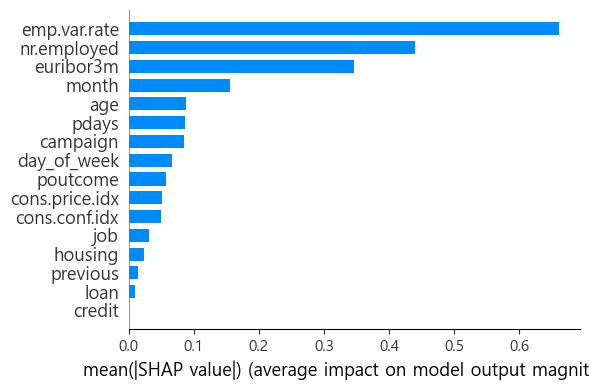

C:\Users\User\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  pl.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_17644\2537009473.py:26: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


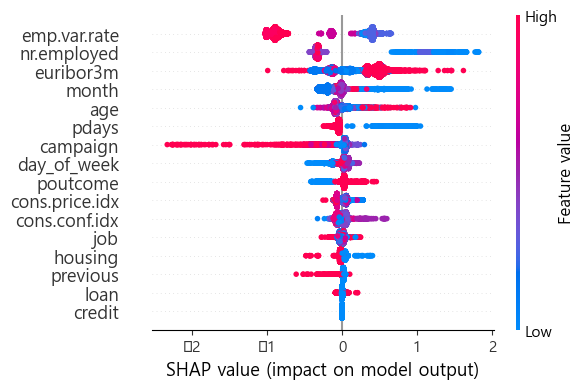

In [58]:
# 정확도는 0.9로 양호
# 마케팅비용 줄이고 실제로 가입할 가능성이 높은 고객만 선별하여 예측한 사람은 거의 맞기를 희망할 경우 정밀도 사용
# 일부 틀린 예측은 괜찮지만 가입할 사람을 빼면 안되므로 본 케이스는 재현율이 중요. 
# 각 피처가 모델예측에 얼마나 기여했는지 수치로 확인하기 위해 SHAP 사용

import shap

import shap
import matplotlib.pyplot as plt

# treeExplainer에 Booster 객체 전달
explainer = shap.TreeExplainer(best_model.get_booster())

# SHAP 값 계산
shap_values = explainer.shap_values(X_test)

# bar 타입 (기여도만)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.gcf().set_size_inches(6, 4)  # width=5, height=3 (인치 단위)
plt.tight_layout()
plt.show()

# 기본 summary plot (값 분포 포함)
shap.summary_plot(shap_values, X_test, show=False)
plt.gcf().set_size_inches(6, 4)
plt.tight_layout()
plt.show()

# SHAP 기반 적금 가입 예측 변수 분석 보고서

## 1. 개요

본 분석은 XGBoost 모델의 예측 결과를 기반으로 SHAP(Shapley Additive Explanations) 기법을 활용하여, 각 피처(변수)가 적금 가입 여부에 미치는 영향을 시각적으로 평가한 결과를 정리한 것이다. SHAP summary plot을 통해 피처별 중요도, 영향 방향성, 값의 크기에 따른 영향 차이를 해석하였다.

---

## 2. 주요 분석 결과

### 2.1 변수 중요도 상위 항목

| 순위 | 변수명           | 설명                           |
|------|------------------|--------------------------------|
| 1    | emp.var.rate     | 고용 변동률                    |
| 2    | nr.employed      | 고용 인구 수                   |
| 3    | euribor3m        | 3개월 유리보 금리              |
| 4    | month            | 마케팅 접촉 시기 (월)          |
| 5    | age              | 고객 나이                      |
| 6    | pdays            | 마지막 접촉 이후 경과일수      |
| 7    | campaign         | 현재 캠페인에서의 접촉 횟수    |

---

### 2.2 변수별 영향 해석

#### (1) 경제 변수 (`emp.var.rate`, `nr.employed`, `euribor3m`)

- 해당 지표들은 모두 모델에서 높은 SHAP 중요도를 나타냄.
- 값이 높을수록 예측 결과는 가입 비선호(음의 방향)로 작용함.
- 이는 경제 여건이 양호할수록 고객의 적금 가입 유인이 낮아짐을 시사함.

#### (2) 마케팅 시기 (`month`)

- 특정 월(예: 5월, 6월 등)에 따라 가입 예측이 크게 좌우됨.
- 시기별 캠페인 전략이 가입 성과에 실질적으로 영향을 미치고 있음.

#### (3) 마케팅 접촉 변수 (`pdays`, `campaign`, `previous`)

- `pdays`: 이전 접촉 이후 시간이 너무 짧거나 길 경우 가입 확률 저하.
- `campaign`: 과도한 반복 접촉 시 오히려 가입 가능성 감소.
- `previous`: 과거 캠페인 반응 이력은 긍정적 신호로 작용하는 경향 있음.

#### (4) 고객 특성 변수 (`age`, `job`, `housing`, `loan`, `credit`)

- `age`: 나이가 많을수록 가입 예측에 긍정적인 기여도가 증가하나 변수 중요성 높지않음.
- `job`: 직업군에 따라 예측 영향 차이 존재하나 유의미한 판별기준 아님.
- `housing`, `loan`, `credit`: 대출 보유자는 가입 가능성 낮으나 감면금리 적용으로 인해 당행 고객 특성상 유의미한 변수일 수 있음. 

---

## 3. 전략적 시사점

### 3.1 캠페인 시기 최적화

- `month` 변수의 SHAP 기여도가 크므로, 월별 성과 분석을 통해 고효율 시점을 선별하고 캠페인을 집중해야 함.

### 3.2 마케팅 접촉 빈도 조절

- `campaign`, `pdays` 등의 변수 영향 분석 결과를 바탕으로, 고객 과접촉을 방지하고 최적 접촉 간격을 설정해야하나 규제로 인해 과도한 접촉은 지양

### 3.3 타겟 고객 세분화

- `job`, `age`, `housing`, `loan` 등 피처 기반으로 가입 확률이 높은 고객군을 선별하여 맞춤형 제안 가능.

### 3.4 경제지표 연동 캠페인 조정

- `emp.var.rate`, `euribor3m` 등 외부 경제 지표가 예측에 큰 영향을 미치므로, 금리 및 고용 환경 변화에 따라 캠페인 시기 및 전략을 유연하게 조정할 필요가 있음.

---

## 4. 결론

본 SHAP 기반 분석은 단순한 피처 중요도를 넘어, 각 변수의 값이 모델 예측에 미치는 정량적 영향까지 명확히 보여준다.  
특히 고객의 금융 상태, 마케팅 접촉 이력, 시기적 요인, 거시 경제 변수 등이 적금 가입 의사결정에 유의미한 영향을 준다는 점에서, 향후 상품 설계 및 마케팅 전략 수립 시 정교한 세분화 전략의 근거 자료로 활용할 수 있다. 덧붙여 본 분석 이전의 별도의 분석에서는 고객과의 통화시간이 절대적으로 가입여부에 영향을 미쳤다는 점에서 고객별 맞춤형 에이전트 사용시간 및 빈도가 높은 고객에 대해서는 적금 및 투자상품의 가입율이 올라갈 것이라고 예상된다. 
